In [1]:
import os

OUTPUT_DIR = "data/exploratory_data_analysis_outputs/image"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder:", os.path.abspath(OUTPUT_DIR))

Output folder: C:\Users\Yzz\DSC 180B\Simulation-coding-exercises-for-teaching-probability-theory\data\exploratory_data_analysis_outputs\image


In [2]:
def save_table(df, name):
    path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"Saved table -> {path}")

In [3]:
import matplotlib.pyplot as plt

import re

def save_current_fig(name):
    # remove illegal filename chars
    name = re.sub(r'[\\/*?:"<>|]', "", name)
    
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure ->", path)

# Score Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [6]:
df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_grades = pd.read_csv("data/cleaned/grades.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

In [7]:
display(df_assess.head())
display(df_grades.head())
display(df_status.head())

,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.6,1.0,0.0,1.0
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0


,id,coding_score,handwritten_score,final_score,final_score_adj
0,0,NaN,NaN,0.737705,0.586066
1,1,0.928571,NaN,0.754098,0.610656
2,3,0.857143,1.0,0.836066,0.479508
3,6,NaN,1.0,0.508197,0.200820
4,9,0.904764,NaN,0.672131,0.471311


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [8]:
df_status = df_status[df_status["completed"] == 1].copy()

print("Completed students:", df_status.shape[0])
display(df_status["section"].value_counts())

Completed students: 31


section
1    11
2     7
3     7
4     6
Name: count, dtype: int64

In [9]:
df_id = (
    df_grades
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("ID-level shape:", df_id.shape)
display(df_id.head())

ID-level shape: (31, 6)


,id,coding_score,handwritten_score,final_score,final_score_adj,section
0,0,NaN,NaN,0.737705,0.586066,1
1,1,0.928571,NaN,0.754098,0.610656,2
2,3,0.857143,1.0,0.836066,0.479508,4
3,6,NaN,1.0,0.508197,0.200820,3
4,9,0.904764,NaN,0.672131,0.471311,2


In [10]:
df_item = (
    df_assess
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("Item-level shape:", df_item.shape)
display(df_item.head())

Item-level shape: (31, 38)


,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level,section
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0,1
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0,2
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0,4
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.6,1.0,0.0,1.0,3
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0,2


In [11]:
df_id["group"] = df_id["section"]
df_item["group"] = df_item["section"]

### 1. Final assessment scores by group（boxplot）

Saved figure -> data/exploratory_data_analysis_outputs/image\Final Assessment Scores by Group.png


C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\1554892452.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


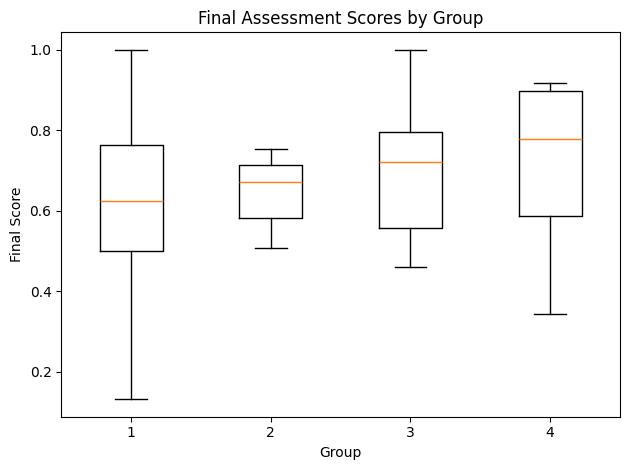

In [12]:
groups = sorted(df_id["group"].unique())
data = [df_id.loc[df_id["group"] == g, "final_score"] for g in groups]

plt.figure()
plt.boxplot(data, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score")
plt.title("Final Assessment Scores by Group")
plt.tight_layout()

save_current_fig("Final Assessment Scores by Group")
plt.show()

### 2. Final assessment scores adjusted for confidence（boxplot）

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3389975434.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_adj, labels=groups, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\Final Assessment Scores (Adjusted) by Group.png


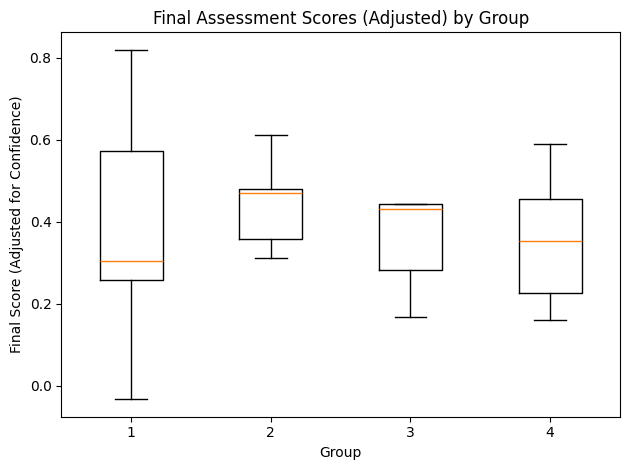

In [13]:
data_adj = [df_id.loc[df_id["group"] == g, "final_score_adj"] for g in groups]

plt.figure()
plt.boxplot(data_adj, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score (Adjusted for Confidence)")
plt.title("Final Assessment Scores (Adjusted) by Group")
plt.tight_layout()

save_current_fig("Final Assessment Scores (Adjusted) by Group")
plt.show()

In [14]:
def boxplot_stats_series(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return pd.Series({
            "n": 0, "mean": np.nan, "std": np.nan,
            "min": np.nan, "q1": np.nan, "median": np.nan, "q3": np.nan, "max": np.nan,
            "iqr": np.nan, "whisker_low": np.nan, "whisker_high": np.nan
        })

    q1 = s.quantile(0.25)
    med = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr

    return pd.Series({
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "q1": q1,
        "median": med,
        "q3": q3,
        "max": s.max(),
        "iqr": iqr,
        "whisker_low": s[s >= low_fence].min(),
        "whisker_high": s[s <= high_fence].max()
    })

s = df_id.groupby("group")["final_score_adj"].apply(boxplot_stats_series)

stats_wide_adj = s.unstack(level=0)

stats_wide_adj.columns = [f"section_{c}" for c in stats_wide_adj.columns]

display(stats_wide_adj)

,section_1,section_2,section_3,section_4
n,11.000000,7.000000,7.000000,6.000000
mean,0.393443,0.416276,0.403981,0.355191
std,0.279789,0.145936,0.201068,0.164990
min,-0.032787,0.155738,0.168033,0.159836
q1,0.258197,0.358607,0.282787,0.227459
median,0.303279,0.471311,0.430328,0.352459
q3,0.571721,0.479508,0.442623,0.455943
max,0.819672,0.610656,0.778689,0.590164
iqr,0.313525,0.120902,0.159836,0.228484
whisker_low,-0.032787,0.311475,0.168033,0.159836


In [15]:
s_raw = df_id.groupby("group")["final_score"].apply(boxplot_stats_series)
stats_wide_raw = s_raw.unstack(level=0)
stats_wide_raw.columns = [f"section_{c}" for c in stats_wide_raw.columns]

display(stats_wide_raw)

,section_1,section_2,section_3,section_4
n,11.000000,7.000000,7.000000,6.000000
mean,0.596125,0.681499,0.697892,0.713115
std,0.283590,0.163348,0.190911,0.230151
min,0.098361,0.508197,0.459016,0.344262
q1,0.500000,0.581967,0.557377,0.586066
median,0.622951,0.672131,0.721311,0.778689
q3,0.762295,0.713115,0.795082,0.897541
max,1.000000,1.000000,1.000000,0.918033
iqr,0.262295,0.131148,0.237705,0.311475
whisker_low,0.131148,0.508197,0.459016,0.344262


### 3. Standard Deviations/Means by subquestion（rescaled 0–1）

In [16]:
score_cols = [c for c in df_item.columns if c.endswith("_score")]

print("Number of subquestions:", len(score_cols))
print(score_cols)

Number of subquestions: 18
['1.1_score', '1.2_score', '1.3_score', '1.4_score', '2.1_score', '2.2_score', '2.3_score', '2.4_score', '3.1_score', '3.2_score', '3.3_score', '3.4_score', '3.5_score', '4.1_score', '5.1_score', '5.2_score', '5.3_score', '5.4_score']


In [17]:
long_scores = (
    df_item[["id"] + score_cols]
    .melt(
        id_vars="id",
        value_vars=score_cols,
        var_name="subquestion",
        value_name="score"
    )
)

# clean subquestion name: '1.1_score' -> '1.1'
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

print("Long score table shape:", long_scores.shape)
display(long_scores.head())

Long score table shape: (558, 3)


,id,subquestion,score
0,0,1.1,0.75
1,1,1.1,0.75
2,3,1.1,1.00
3,6,1.1,1.00
4,9,1.1,0.50


In [18]:
std_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(std_score=("score", "std"))
    .reset_index()
    .sort_values("std_score", ascending=False)
)

In [19]:
mean_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(mean_score=("score", "mean"))
    .reset_index()
    .sort_values("mean_score")
)

In [20]:
subquestion_summary = (
    long_scores
    .groupby("subquestion")
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
    .sort_values("subquestion")
)

display(subquestion_summary)

,subquestion,mean_score,std_score,n
0,1.1,0.782258,0.271891,31
1,1.2,0.845161,0.308587,31
2,1.3,0.774194,0.425024,31
3,1.4,0.750000,0.392641,31
4,2.1,0.709677,0.461414,31
5,2.2,0.870968,0.340777,31
6,2.3,1.000000,0.000000,31
7,2.4,0.677419,0.475191,31
8,3.1,0.774194,0.425024,31
9,3.2,0.645161,0.486373,31


### 4. Boxplots by section for any subquestions of interest

In [21]:
# helper function to add rank labels
def add_rank_label(df, label_prefix, score_col, ascending):
    df = df.sort_values(score_col, ascending=ascending).head(2).copy()
    df["selection_reason"] = [
        f"1st {label_prefix}",
        f"2nd {label_prefix}"
    ]
    return df


# 1) highest mean
highest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest mean",
    score_col="mean_score",
    ascending=False
)

# 2) lowest mean
lowest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest mean",
    score_col="mean_score",
    ascending=True
)

# 3) highest std
highest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest std",
    score_col="std_score",
    ascending=False
)

# 4) lowest std
lowest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest std",
    score_col="std_score",
    ascending=True
)

# combine all
interest_subqs = pd.concat([
    highest_mean_2,
    lowest_mean_2,
    highest_std_2,
    lowest_std_2
])

# merge labels if a subquestion appears multiple times
interest_subqs = (
    interest_subqs
    .groupby(["subquestion", "mean_score", "std_score", "n"], as_index=False)
    .agg({
        "selection_reason": lambda x: "; ".join(sorted(set(x)))
    })
    .sort_values("subquestion")
)

display(interest_subqs)

,subquestion,mean_score,std_score,n,selection_reason
0,1.1,0.782258,0.271891,31,2nd lowest std
1,2.2,0.870968,0.340777,31,2nd highest mean
2,2.3,1.000000,0.000000,31,1st highest mean; 1st lowest std
3,3.4,0.580645,0.501610,31,1st highest std
4,3.5,0.387097,0.495138,31,2nd lowest mean
5,5.2,0.322581,0.475191,31,1st lowest mean
6,5.4,0.419355,0.501610,31,2nd highest std


In [22]:
# Sanity check: 3.4 and 4.1 are different subquestions by design.
# We test whether their raw score vectors differ in the dataset; if this returns True,
# the two items happen to have identical observed scores in the current sample.
s34 = long_scores[long_scores["subquestion"] == "3.4"]["score"].reset_index(drop=True)
s41 = long_scores[long_scores["subquestion"] == "4.1"]["score"].reset_index(drop=True)

(s34 == s41).all()

np.False_

In [23]:
# merge section info
long_scores_sec = long_scores.merge(
    df_item[["id", "section"]].drop_duplicates(),
    on="id",
    how="left"
)

Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_1.1.png


C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


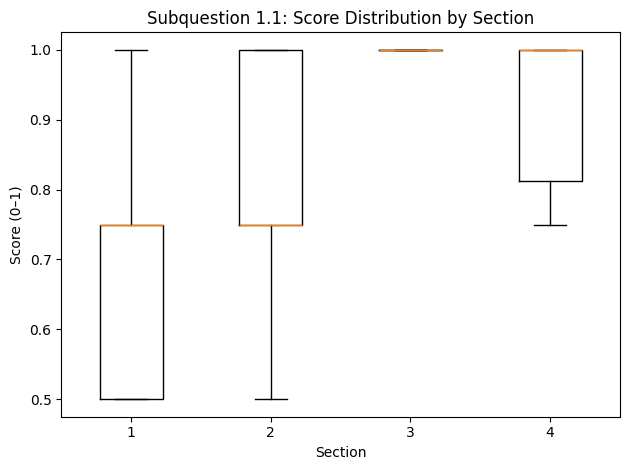

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_2.2.png


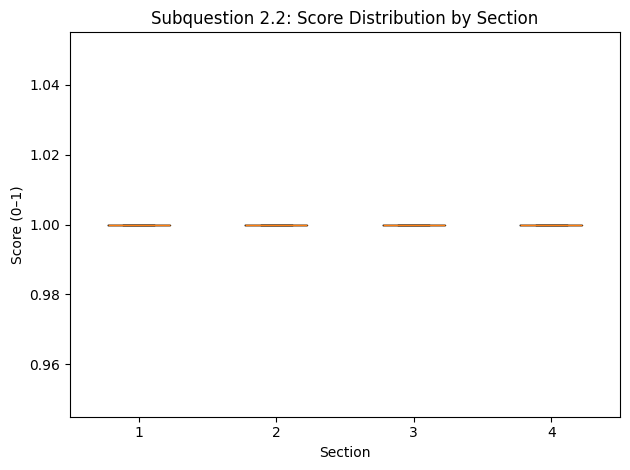

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_2.3.png


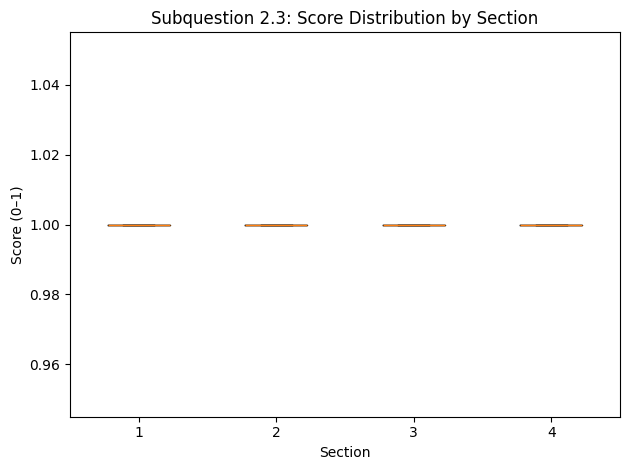

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_3.4.png


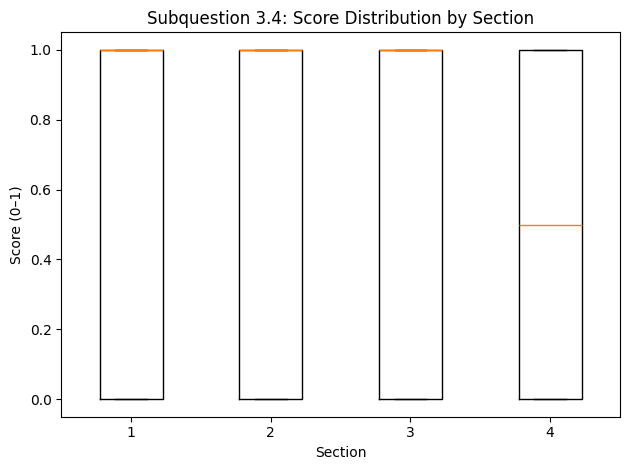

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_3.5.png


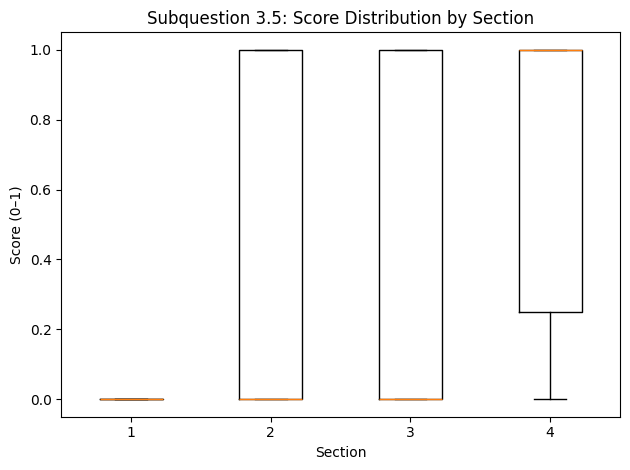

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_5.2.png


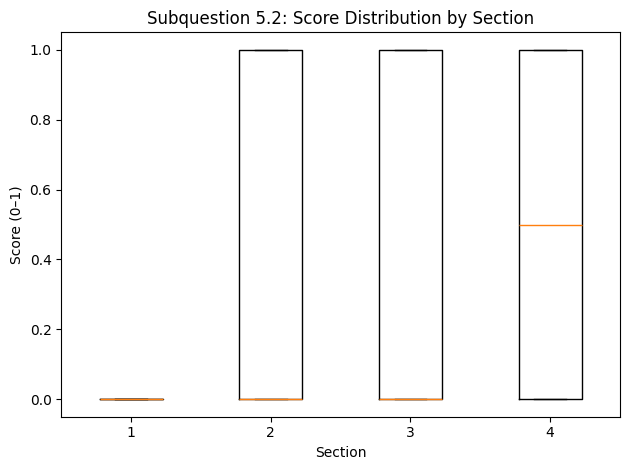

C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\3229870680.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


Saved figure -> data/exploratory_data_analysis_outputs/image\boxplot_subq_5.4.png


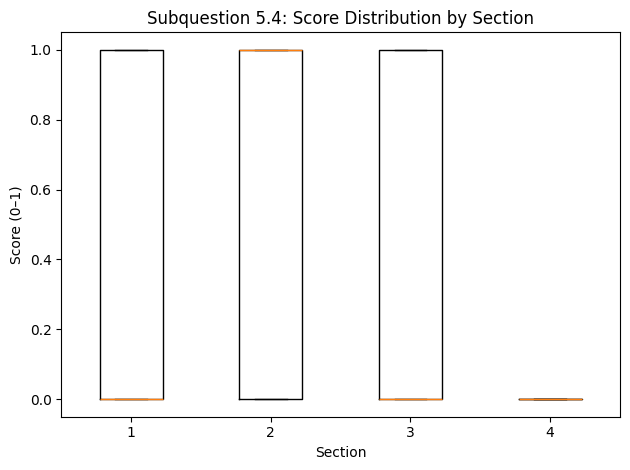

In [24]:
import matplotlib.pyplot as plt

sections = sorted(long_scores_sec["section"].unique())

for sq in interest_subqs["subquestion"]:
    data = [
        long_scores_sec.loc[
            (long_scores_sec["subquestion"] == sq) &
            (long_scores_sec["section"] == sec),
            "score"
        ]
        for sec in sections
    ]
    
    plt.figure()
    plt.boxplot(data, labels=sections, showfliers=False)
    plt.xlabel("Section")
    plt.ylabel("Score (0–1)")
    plt.title(f"Subquestion {sq}: Score Distribution by Section")
    plt.tight_layout()

    save_current_fig(f"boxplot_subq_{sq}")
    plt.show()

### Completeness by group

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df_status = pd.read_csv("data/cleaned/status.csv")

print(df_status.shape)
display(df_status.head())

(94, 3)


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [26]:
df_status["completed"] = (
    df_status["completed"]
    .astype(str)
    .str.upper()
    .map({"TRUE": True, "FALSE": False})
)

print("Completed value counts:")
display(df_status["completed"].value_counts(dropna=False))

Completed value counts:


completed
False    63
True     31
Name: count, dtype: int64

In [27]:
completeness_by_section = (
    df_status
    .groupby("section")
    .agg(
        n_total=("completed", "size"),
        n_completed=("completed", "sum"),      # True = 1
        completion_rate=("completed", "mean")  # proportion TRUE
    )
    .reset_index()
)

display(completeness_by_section)

,section,n_total,n_completed,completion_rate
0,1,24,11,0.458333
1,2,24,7,0.291667
2,3,23,7,0.304348
3,4,23,6,0.260870


Saved figure -> data/exploratory_data_analysis_outputs/image\Task Completion Rate by Section.png


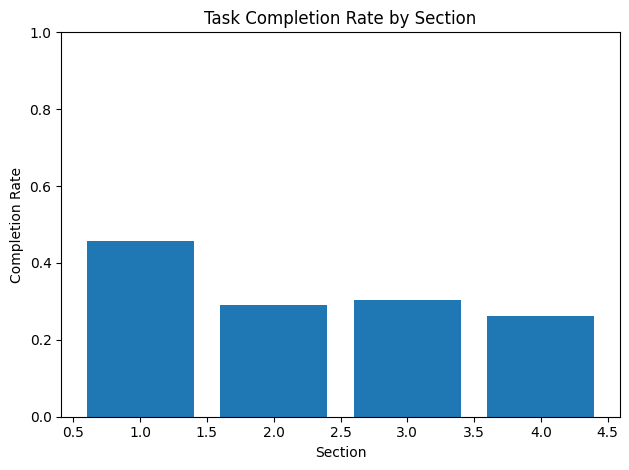

In [28]:
plt.figure()
plt.bar(
    completeness_by_section["section"],
    completeness_by_section["completion_rate"]
)
plt.xlabel("Section")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.title("Task Completion Rate by Section")
plt.tight_layout()

save_current_fig("Task Completion Rate by Section")
plt.show()

# Confidence Level Analysis

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

# keep only completed students
df_status = df_status[df_status["completed"] == 1].copy()

# merge assessment + section
df_item = df_assess.merge(df_status[["id", "section"]], on="id", how="inner")
print("df_item shape:", df_item.shape)

df_item shape: (31, 38)


In [30]:
# identify columns
score_cols = [c for c in df_item.columns if c.endswith("_score")]
conf_cols  = [c for c in df_item.columns if c.endswith("_confident_level")]

print("Num score cols:", len(score_cols))
print("Num conf cols:", len(conf_cols))

# reshape scores long
long_scores = (
    df_item[["id", "section"] + score_cols]
    .melt(id_vars=["id", "section"], value_vars=score_cols,
          var_name="subquestion", value_name="score")
)
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

# reshape confidence long
long_conf = (
    df_item[["id", "section"] + conf_cols]
    .melt(id_vars=["id", "section"], value_vars=conf_cols,
          var_name="subquestion", value_name="confidence")
)
long_conf["subquestion"] = long_conf["subquestion"].str.replace("_confident_level", "", regex=False)

# merge into one tidy table: one row per (id, section, subquestion)
long_sc = long_scores.merge(long_conf, on=["id", "section", "subquestion"], how="inner")

# type cleaning
long_sc["score"] = pd.to_numeric(long_sc["score"], errors="coerce")
long_sc["confidence"] = pd.to_numeric(long_sc["confidence"], errors="coerce")

print("long_sc shape:", long_sc.shape)
display(long_sc.head())

Num score cols: 18
Num conf cols: 18
long_sc shape: (558, 5)


,id,section,subquestion,score,confidence
0,0,1,1.1,0.75,4.0
1,1,2,1.1,0.75,5.0
2,3,4,1.1,1.00,4.0
3,6,3,1.1,1.00,2.0
4,9,2,1.1,0.50,4.0


In [31]:
conf_fill_by_section = (
    long_sc
    .groupby("section", dropna=False)
    .agg(
        n_rows=("confidence", "size"),
        conf_non_missing=("confidence", lambda s: s.notna().sum()),
        conf_fill_rate=("confidence", lambda s: s.notna().mean())
    )
    .reset_index()
)

display(conf_fill_by_section)

,section,n_rows,conf_non_missing,conf_fill_rate
0,1,198,188,0.949495
1,2,126,123,0.976190
2,3,126,126,1.000000
3,4,108,100,0.925926


Saved figure -> data/exploratory_data_analysis_outputs/image\Confidence Distribution by Section (Completed only).png


C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\4136443590.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


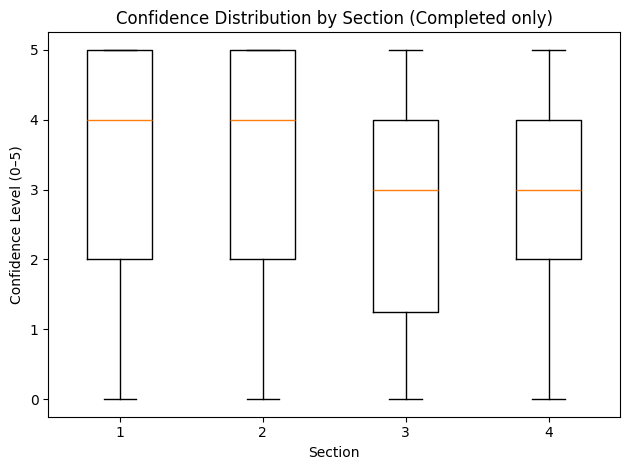

In [32]:
conf_nonmiss = long_sc.dropna(subset=["confidence"]).copy()
sections = sorted(conf_nonmiss["section"].unique())

data = [conf_nonmiss.loc[conf_nonmiss["section"] == sec, "confidence"] for sec in sections]

plt.figure()
plt.boxplot(data, labels=sections, showfliers=False)
plt.xlabel("Section")
plt.ylabel("Confidence Level (0–5)")
plt.title("Confidence Distribution by Section (Completed only)")
plt.tight_layout()

save_current_fig("Confidence Distribution by Section (Completed only)")
plt.show()

,confidence,n,mean_score,std_score
0,0.0,68,0.260294,0.429557
1,1.0,45,0.387778,0.475198
2,2.0,63,0.627778,0.473046
3,3.0,105,0.730000,0.424241
4,4.0,135,0.864444,0.318981
5,5.0,121,0.907851,0.278688


Saved figure -> data/exploratory_data_analysis_outputs/image\Overall Calibration Mean Score by Confidence.png


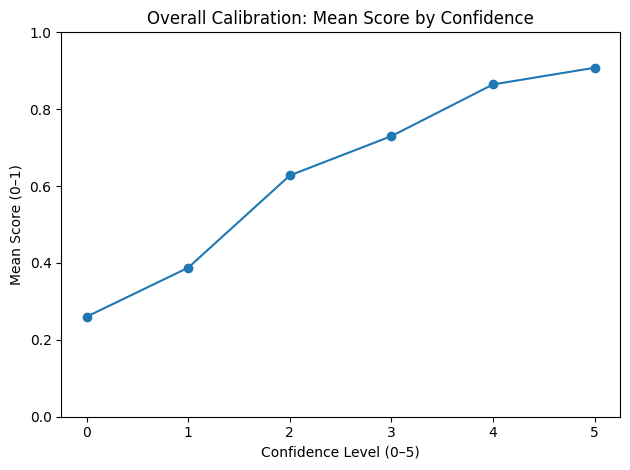

In [33]:
calib_overall = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby("confidence", dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values("confidence")
)

display(calib_overall)

plt.figure()
plt.plot(calib_overall["confidence"], calib_overall["mean_score"], marker="o")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Overall Calibration: Mean Score by Confidence")
plt.ylim(0, 1)
plt.tight_layout()

save_current_fig("Overall Calibration: Mean Score by Confidence")
plt.show()

,section,confidence,n,mean_score
0,1,0.0,30,0.290000
1,1,1.0,16,0.312500
2,1,2.0,13,0.403846
3,1,3.0,29,0.701724
4,1,4.0,40,0.765000
5,1,5.0,60,0.929167
6,2,0.0,8,0.375000
7,2,1.0,10,0.305000
8,2,2.0,14,0.700000
9,2,3.0,26,0.661538


Saved figure -> data/exploratory_data_analysis_outputs/image\Calibration by Section Mean Score vs Confidence.png


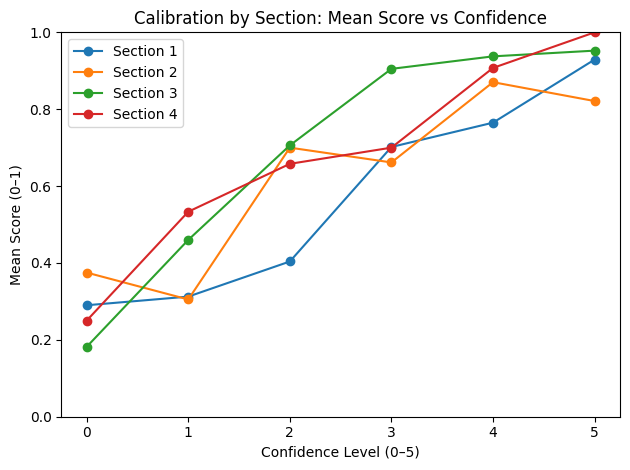

In [34]:
calib_by_section = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["section", "confidence"], dropna=False)
    .agg(n=("score", "size"), mean_score=("score", "mean"))
    .reset_index()
    .sort_values(["section", "confidence"])
)

display(calib_by_section.head(20))

plt.figure()
for sec in sorted(calib_by_section["section"].unique()):
    tmp = calib_by_section[calib_by_section["section"] == sec]
    plt.plot(tmp["confidence"], tmp["mean_score"], marker="o", label=f"Section {sec}")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Calibration by Section: Mean Score vs Confidence")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

save_current_fig("Calibration by Section: Mean Score vs Confidence")
plt.show()

In [35]:
calib_by_subq = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["subquestion", "confidence"], dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values(["subquestion", "confidence"])
)

display(calib_by_subq.head(30))

# (Optional) pivot to make it easy to compare across confidence levels
calib_pivot = calib_by_subq.pivot(index="subquestion", columns="confidence", values="mean_score")
display(calib_pivot)

,subquestion,confidence,n,mean_score,std_score
0,1.1,1.0,1,1.000000,NaN
1,1.1,2.0,4,0.562500,0.426956
2,1.1,3.0,6,0.791667,0.245798
3,1.1,4.0,15,0.800000,0.270581
4,1.1,5.0,5,0.850000,0.136931
5,1.2,1.0,1,0.800000,NaN
6,1.2,2.0,5,0.600000,0.547723
7,1.2,3.0,11,0.927273,0.161808
8,1.2,4.0,7,0.942857,0.097590
9,1.2,5.0,7,0.800000,0.382971


confidence,0.0,1.0,2.0,3.0,4.0,5.0
subquestion,,,,,,
1.1,NaN,1.000000,0.562500,0.791667,0.800000,0.850000
1.2,NaN,0.800000,0.600000,0.927273,0.942857,0.800000
1.3,1.000000,0.666667,0.600000,0.714286,1.000000,1.000000
1.4,0.500000,0.125000,0.812500,0.650000,0.944444,1.000000
2.1,0.000000,NaN,0.000000,0.666667,0.833333,0.818182
2.2,1.000000,NaN,0.666667,0.500000,1.000000,1.000000
2.3,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
2.4,0.000000,0.666667,0.000000,0.666667,0.666667,1.000000
3.1,NaN,0.000000,0.500000,0.333333,1.000000,0.882353


In [36]:
# overall correlation
tmp = long_sc.dropna(subset=["confidence", "score"])
overall_corr = tmp["confidence"].corr(tmp["score"])
print("Overall Pearson corr(confidence, score):", overall_corr)

# correlation by section
corr_by_section = (
    tmp.groupby("section")
       .apply(lambda g: g["confidence"].corr(g["score"]))
       .reset_index(name="corr_conf_score")
)
display(corr_by_section)

Overall Pearson corr(confidence, score): 0.49599690948705266


C:\Users\Yzz\AppData\Local\Temp\ipykernel_24512\1270350930.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["confidence"].corr(g["score"]))


,section,corr_conf_score
0,1,0.542183
1,2,0.360612
2,3,0.628891
3,4,0.420669


In [37]:
tables = [
    stats_wide_raw,
    stats_wide_adj,
    subquestion_summary,
    interest_subqs,
    conf_fill_by_section,
    calib_overall,
    calib_by_section,
    calib_by_subq,
    corr_by_section
]

names = [
    "stats_wide_raw",
    "stats_wide_adj",
    "subquestion_summary",
    "interest_subqs",
    "conf_fill_by_section",
    "calib_overall",
    "calib_by_section",
    "calib_by_subq",
    "corr_by_section"
]

for df, name in zip(tables, names):
    df.to_csv(f"data/exploratory_data_analysis_outputs/table/{name}.csv", index=False)
    print(f"Saved -> data/exploratory_data_analysis_outputs/table/{name}.csv")

Saved -> data/exploratory_data_analysis_outputs/table/stats_wide_raw.csv
Saved -> data/exploratory_data_analysis_outputs/table/stats_wide_adj.csv
Saved -> data/exploratory_data_analysis_outputs/table/subquestion_summary.csv
Saved -> data/exploratory_data_analysis_outputs/table/interest_subqs.csv
Saved -> data/exploratory_data_analysis_outputs/table/conf_fill_by_section.csv
Saved -> data/exploratory_data_analysis_outputs/table/calib_overall.csv
Saved -> data/exploratory_data_analysis_outputs/table/calib_by_section.csv
Saved -> data/exploratory_data_analysis_outputs/table/calib_by_subq.csv
Saved -> data/exploratory_data_analysis_outputs/table/corr_by_section.csv


# Report

This exploratory data analysis examines student assessment outcomes across four instructional groups that differ in how students engaged with the material:

* **Section 1:** Neither coding nor handwritten work
* **Section 2:** Coding only
* **Section 3:** Handwritten only
* **Section 4:** Both coding and handwritten work

The analysis focuses on overall performance, subquestion-level variability, confidence calibration, and task completion patterns to understand how these engagement modes relate to assessment outcomes.


## **Overall Performance Patterns**

The boxplots of final assessment scores by group suggest moderate differences across sections. Sections involving structured engagement (Sections 2, 3, and 4) generally show higher median scores compared with Section 1, which lacks both coding and handwritten practice.

Notably, **Section 4 (both coding and handwritten)** exhibits relatively strong performance with a higher upper range, whereas **Section 1** displays greater variability and lower adjusted scores. This pattern suggests that structured forms of engagement may support more consistent learning outcomes, though causal conclusions cannot be drawn from exploratory analysis alone.

When scores are adjusted for confidence levels, overall scores decrease across all groups. However, the reduction appears most pronounced for Section 1. This may indicate that students without structured engagement report lower confidence relative to their raw performance, or alternatively that confidence calibration differs across instructional modes.


## **Subquestion-Level Variation**

Analysis of subquestion means and standard deviations (rescaled to the 0–1 score range) reveals substantial variability in item difficulty.

Some questions show **ceiling effects** — certain subquestions exhibit near-perfect scores across all sections, limiting their ability to discriminate between groups. Other subquestions demonstrate much higher variability, particularly those identified as having higher standard deviations or lower mean scores in the summary tables. These items appear to drive most of the differences observed in overall assessment performance.

Boxplots by section for selected subquestions indicate that differences between instructional modes are not uniform across all items. Some questions show relatively consistent performance across sections, while others reveal stronger differentiation — especially between Section 1 and the structured engagement groups.


## **Confidence Calibration**

Confidence-level analysis provides additional insight into how students perceive their own performance.

The overall calibration plot shows a clear positive relationship between confidence level and average score: higher self-reported confidence generally corresponds to higher correctness. This suggests that students are reasonably well calibrated in assessing their understanding.

When examined by section, calibration patterns differ somewhat. Some sections show stronger alignment between confidence and accuracy than others, indicating possible variation in how students interpret uncertainty or evaluate their own responses.

Correlation analysis between confidence and scores confirms a moderate positive relationship overall, with variability across sections.


## **Task Completion Patterns**

Completion rates also vary across sections. According to the completion summary table, **Section 1 shows the highest completion proportion**, while Sections 2–4 exhibit somewhat lower rates.

This may reflect differences in workload perception, engagement style, or task difficulty under different instructional formats.

Completion behavior is important when interpreting score differences because lower completion rates may bias observed performance — especially if non-completion is not random.


## **Overall Interpretation**

Taken together, the exploratory analysis suggests that structured engagement — whether through coding, handwritten work, or both — is associated with more stable performance patterns compared with having neither form of engagement.

Confidence calibration appears generally reasonable but varies across groups, and completion rates differ in ways that may influence performance interpretation.

These findings provide useful descriptive insights but should not be interpreted causally without further controlled analysis.